In [1]:
import sys
import os
from typing import *
import argparse
import time
import datetime
import json
import math
from pathlib import Path

import torch
import torch.backends.cudnn as cudnn
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from torchvision.transforms import InterpolationMode
import timm.optim.optim_factory as optim_factory
import einops

import misc
from misc import NativeScalerWithGradNormCount as NativeScaler
import vit
import resnet
import lr_sched


/home/renkaiwen/.conda/envs/sl_vit_cu118/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [3]:
net = resnet.__dict__["sll_resnet50"]()

In [4]:
ckpt = torch.load("./logs/20240909-1/checkpoint-2.pth", map_location="cpu")
net.load_state_dict(ckpt['model'])

/tmp/ipykernel_11955/186537505.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("./logs/20240909-1/checkpoint-2.pth", map_location="cpu")


<All keys matched successfully>

In [5]:
transform_train = transforms.Compose([
        # transforms.RandomResizedCrop(args.input_size, scale=(0.2, 1.0), interpolation=InterpolationMode.BICUBIC),  # 3 is bicubic
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomRotation((0, 360)) if args.rot_aug else lambda x: x,
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
dataset = datasets.ImageFolder("./data/Imagenet-1K/train/", transform=transform_train)
dataloader = torch.utils.data.DataLoader(dataset)

In [6]:
samples, _ = next(iter(dataloader))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


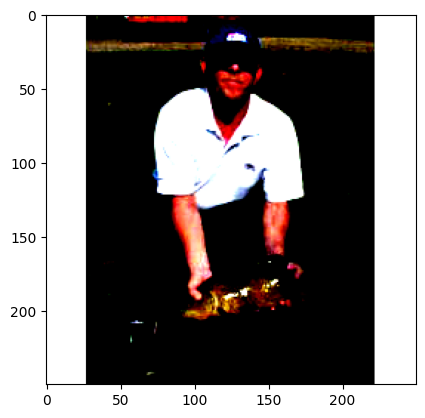

In [10]:
import matplotlib.pyplot as plt
import einops as eps

plt.imshow(eps.rearrange(samples[0], 'c h w -> h w c'))

In [11]:
samples.to("cuda:0")
net.to("cuda:0")

SLL_ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=

In [14]:
feat = net.forward_encoder(samples.to("cuda:0"))

In [30]:
feat2 = net.forward_encoder(torch.flip(samples.to("cuda:0"), dims=[3]))

In [31]:
hfeat = net.hf_operator(eps.rearrange(feat, 'b c h w -> b c (h w)').mean(-1))

In [32]:
torch.nn.functional.mse_loss(hfeat, eps.rearrange(feat2, 'b c h w -> b c (h w)').mean(-1))

tensor(0.0179, device='cuda:0', grad_fn=<MseLossBackward0>)